Escala de peso para clases: 0.4760

Buscando mejores hiperparámetros (Esto puede tardar)...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Mejores parámetros encontrados: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 6, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}
Mejor ROC-AUC en CV: 0.9278

── XGBoost (Optimizado) ──
              precision    recall  f1-score   support

           0       0.89      0.77      0.82        64
           1       0.90      0.96      0.93       136

    accuracy                           0.90       200
   macro avg       0.89      0.86      0.87       200
weighted avg       0.89      0.90      0.89       200

CV Accuracy : 0.9000 ± 0.0247
CV F1       : 0.9003 ± 0.0239
CV AUC-ROC  : 0.9335 ± 0.0354


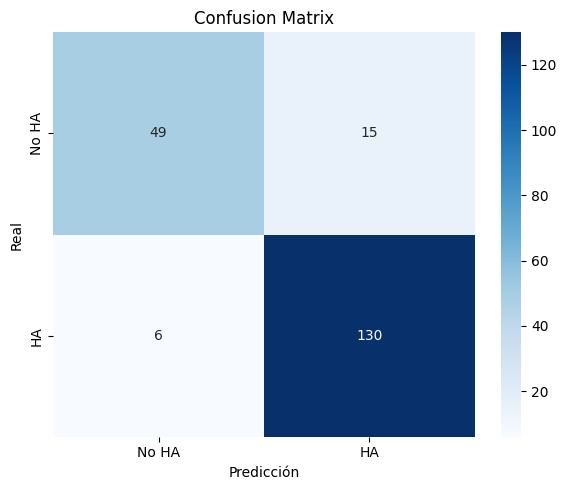

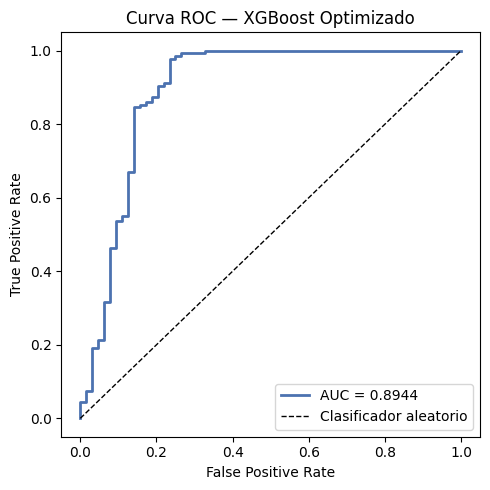


Generando explicaciones SHAP...

--- 7.1 Importancia global ---


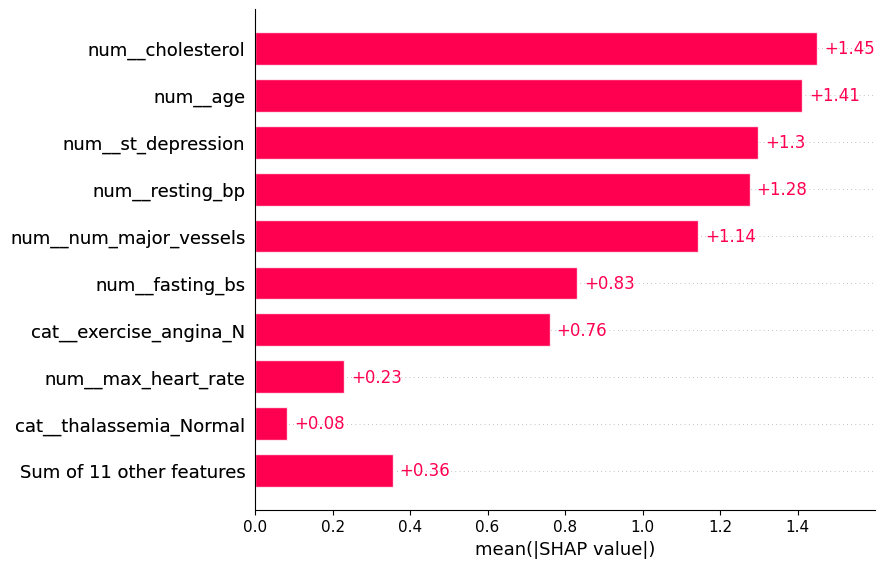


--- 7.2 Distribución y dirección ---


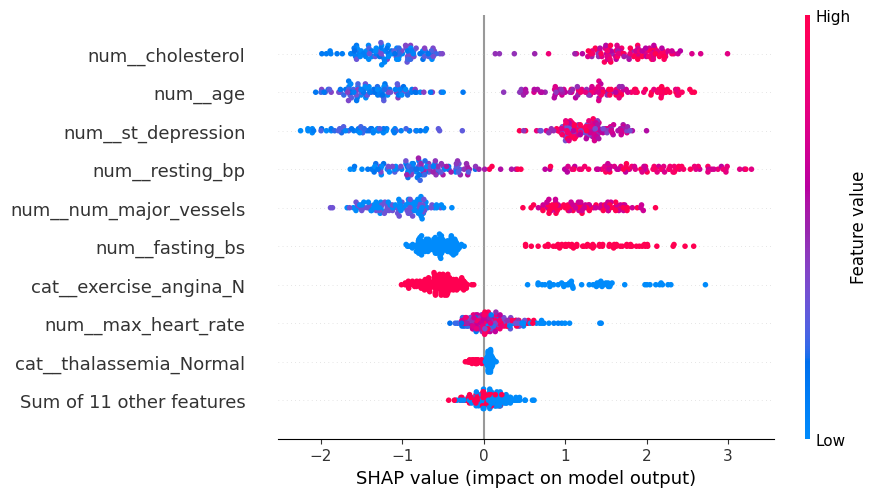


--- 7.3 Explicación del primer paciente ---


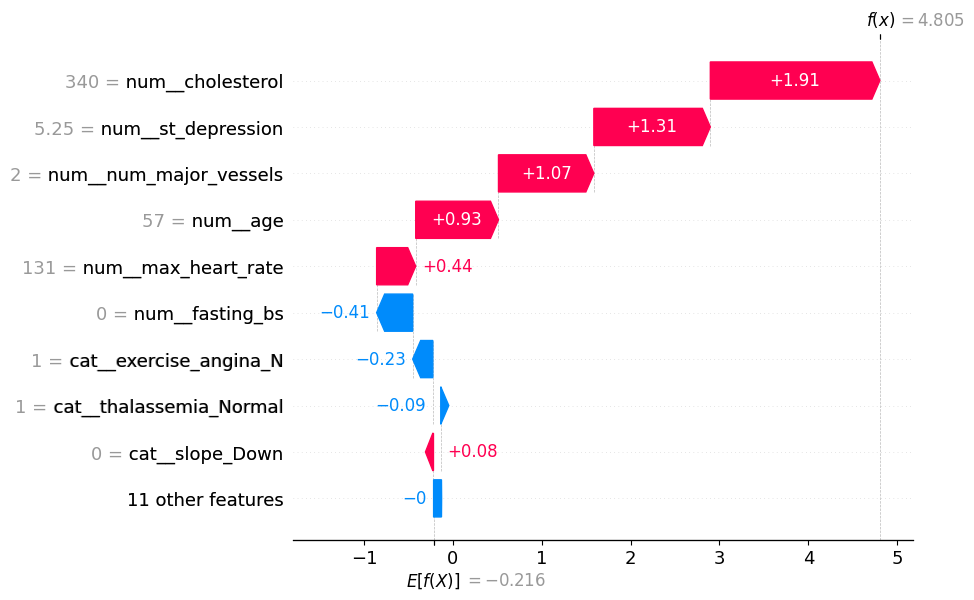


--- 7.4 Heatmap ---


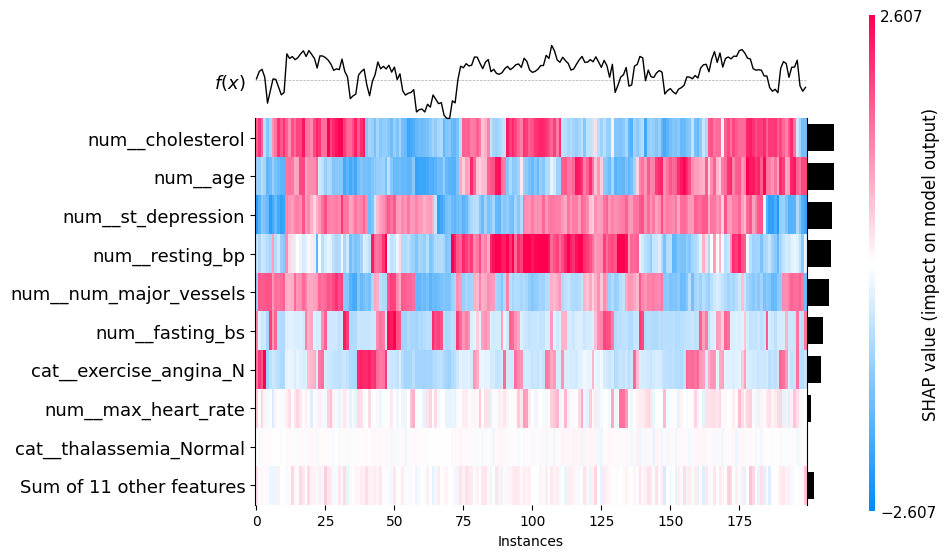

<Axes: xlabel='Instances'>

In [1]:
import os
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, auc, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

df = pd.read_csv("synthetic_heart_attack_dataset.csv")

df = df.drop(columns=["patient_id"], errors="ignore") # Elimina la columna/s que no se necesitan
df = df.dropna()
df = df.drop_duplicates()

# Separamos los datos
X = df.drop("heart_attack", axis=1)
y = df["heart_attack"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Dividimos los datos 80% para entrenar y el 20% para prueba

# Definimos qué columnas son categóricas (texto) y cuáles son numéricas
cat_cols = ["sex", "ecg_result", "exercise_angina", "slope", "thalassemia"]
num_cols = [col for col in X.columns if col not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols) # Convierte las columnas de texto a números con OneHotEncoding
    ]
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"Escala de peso para clases: {scale:.4f}")

# Creamos el modelo
pipeline = Pipeline(steps=[
    ("preprossesor", preprocessor),
    ("classifier", XGBClassifier(
        scale_pos_weight=scale,
        random_state=42,
        n_jobs=-1,
        eval_metrics="logloss",
        verbosity=0
    ))
])

print("\nBuscando mejores hiperparámetros (Esto puede tardar)...")

# Crea varios modelos con estos paramentros y selecciona el mejor
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [4, 6, 8],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__subsample": [0.8, 1.0]
}

# GridSearchCV se encargar de crear los modelos
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train) # Entrena lo modelo
print(f"Mejores parámetros encontrados: {grid.best_params_}")
print(f"Mejor ROC-AUC en CV: {grid.best_score_:.4f}")

modelo = grid.best_estimator_ # Selecciona el mejor modelo

pred = modelo.predict(X_test) # Probamos el modelo con los datos de prueba
print("\n── XGBoost (Optimizado) ──")
print(classification_report(y_test, pred))

# Validación cruzada con 5 folds para medir estabilidad del mode
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="accuracy")
f1 = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="f1_weighted")
auc_cv = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="roc_auc")

print(f"CV Accuracy : {acc.mean():.4f} ± {acc.std():.4f}")
print(f"CV F1       : {f1.mean():.4f} ± {f1.std():.4f}")
print(f"CV AUC-ROC  : {auc_cv.mean():.4f} ± {auc_cv.std():.4f}")

# Grafica Confusion Matrix, Nos muestra claramente cuántos aciertos hubo y en qué se confundió el modelo
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No HA", "HA"], yticklabels=["No HA", "HA"])
ax.set_title("Confusion Matrix")
ax.set_ylabel("Real")
ax.set_xlabel("Predicción")
plt.tight_layout()
plt.show()
plt.close("all")

# Grafica Curva Roc Muestra qué tan bueno es el modelo distinguiendo entre clases
proba_scores = modelo.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_scores)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"AUC = {roc_auc:.4f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curva ROC — XGBoost Optimizado")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()
plt.close("all") # Cerramos los gráficos anteriores para no mezclarlos con los de SHAP

print("\nGenerando explicaciones SHAP...")

# Graficas con Shap Nos explica detalldamente como funciona el modelo
X_sample = X_test[:500].copy()

# Extraemos el preprocesador y el modelo del pipeline entrenado
preprocessor_step = modelo.named_steps["preprossesor"]
model_xgb = modelo.named_steps["classifier"]

# Transformamos los datos a formato numérico para que SHAP los entienda
X_sample_transformed = preprocessor_step.transform(X_sample)

# Obtenemos los nombres de las columnas generadas por el OneHotEncoder
feature_names = preprocessor_step.get_feature_names_out()
X_sample_df = pd.DataFrame(X_sample_transformed, columns=feature_names)

# Calculamos valores SHAP
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer(X_sample_df)

# Gráficos SHAP
print("\n--- 7.1 Importancia global ---")
shap.plots.bar(shap_values, max_display=10)

print("\n--- 7.2 Distribución y dirección ---")
shap.plots.beeswarm(shap_values, max_display=10)

print("\n--- 7.3 Explicación del primer paciente ---")
shap.plots.waterfall(shap_values[0], max_display=10)

print("\n--- 7.4 Heatmap ---")
shap.plots.heatmap(shap_values)